In [1]:
# importing only what I need right now (I'll add more libs later in their own sections)
import pandas as pd
import numpy as np

# random seed so my results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
# path stuff - keeping it simple
PGCB_PATH    = "PGCB_date_power_demand.xlsx"
WEATHER_PATH = "weather_data.xlsx"
ECON_PATH    = "economic_full_1.csv"

# load the three files
pgcb_raw    = pd.read_excel(PGCB_PATH)
# weather excel has some random lat long data on the first 3 rows, real headers are on row 4

weather_raw = pd.read_excel(WEATHER_PATH, header=3)
econ_raw    = pd.read_csv(ECON_PATH)

print("PGCB shape   :", pgcb_raw.shape)
print("Weather shape:", weather_raw.shape)
print("Econ shape   :", econ_raw.shape)


PGCB shape   : (92650, 15)
Weather shape: (107304, 10)
Econ shape   : (1516, 69)


In [3]:
# PGCB columns
print("PGCB columns:", list(pgcb_raw.columns))
pgcb_raw.head()


PGCB columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [4]:
# weather columns
print("Weather columns:", list(weather_raw.columns))
weather_raw.head()


Weather columns: ['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']


,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [ ]:
# economic data,
print("Econ columns (first 10):", list(econ_raw.columns)[:10])
print("Econ columns (last 5):", list(econ_raw.columns)[-5:])
econ_raw.head()


Econ columns (first 10): ['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966']
Econ columns (last 5): ['2021', '2022', '2023', '2024', '2025']


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [ ]:
# 2.1 standardise the datetime column
pgcb = pgcb_raw.copy()
pgcb['datetime'] = pd.to_datetime(pgcb['datetime'])  # just to be safe

# sort chronologically
pgcb = pgcb.sort_values('datetime').reset_index(drop=True)
print("First date:", pgcb['datetime'].min())
print("Last  date:", pgcb['datetime'].max())


First date: 2015-04-19 00:00:00
Last  date: 2025-06-17 12:00:00


In [ ]:
# 2.2 half-hour rows 
# I saw that most rows are at HH:00 but some are at HH:30 (they correspond to
# evening peaks I think - the 'remarks' column says 'Evening_Peak' for many of them).
# Since I want a only hourly series I'll just keep the HH:00 rows and ignore the half-hour ones.
mins = pgcb['datetime'].dt.minute.unique()
print("Unique minute values:", mins)

top_of_hour = pgcb['datetime'].dt.minute == 0
print("non-hourly rows that will be dropped:", (~top_of_hour).sum())

pgcb = pgcb[top_of_hour].reset_index(drop=True)
print("Shape after keeping only top-of-hour rows:", pgcb.shape)


Unique minute values: [ 0 30]
non-hourly rows that will be dropped: 4181
Shape after keeping only top-of-hour rows: (88469, 15)


In [ ]:
#  2.3 duplicate timestamps 
# Some timestamps appear more than once, probably re-submissions on PGCB's side.
# Safer to keep the first occurrence and drop the rest.
dup_count = pgcb.duplicated(subset=['datetime']).sum()
print("duplicate timestamps:", dup_count)

pgcb = pgcb.drop_duplicates(subset=['datetime'], keep='first').reset_index(drop=True)
print("after dedupe:", pgcb.shape)


duplicate timestamps: 423
after dedupe: (88046, 15)


In [ ]:
# quick look at demand_mw statss just to see where the weird values are
print(pgcb['demand_mw'].describe())
# also peek at the top 10 biggest and smallest
print('\nBiggest values:\n', pgcb.nlargest(10, 'demand_mw')[['datetime','demand_mw']])
print('\nSmallest values:\n', pgcb.nsmallest(10, 'demand_mw')[['datetime','demand_mw']])


count     88046.000000
mean       8776.296209
std        2709.835241
min           6.000000
25%        6769.000000
50%        8381.000000
75%       10590.000000
max      121000.000000
Name: demand_mw, dtype: float64

Biggest values:
                  datetime  demand_mw
77803 2024-04-16 07:00:00     121000
73294 2023-10-11 03:00:00     117000
79672 2024-07-03 05:00:00     111140
19927 2017-08-26 15:00:00      80689
17528 2017-05-17 12:00:00      74223
31260 2018-12-18 08:00:00      55639
73134 2023-10-04 09:00:00      20587
78128 2024-04-29 20:00:00      17200
78104 2024-04-28 20:00:00      17150
78129 2024-04-29 21:00:00      17100

Smallest values:
                  datetime  demand_mw
23205 2018-01-14 11:00:00          6
21144 2017-10-16 09:00:00         73
14283 2016-12-09 20:00:00         80
80550 2024-08-08 23:00:00        143
23289 2018-01-17 23:00:00        236
44162 2020-06-12 02:00:00        254
80203 2024-07-25 10:00:00        436
48790 2020-12-22 04:00:00        556
22991 2

In [ ]:
#  2.4 rolling-median / IQR anomaly cleanup 
# I first tried just "drop anything outside 3*IQR of the whole series" but that
# was too aggressive - it kills legit summer peaks. So I switched to a ROLLING
# median (a moving local baseline) and looked at the residual from that. 

demand = pgcb[['datetime','demand_mw']].copy().set_index('datetime').sort_index()

WINDOW = 25   # ~one day of hours, centered
roll_med = demand['demand_mw'].rolling(WINDOW, center=True, min_periods=5).median()

residual = demand['demand_mw'] - roll_med

q1, q3 = residual.quantile(0.25), residual.quantile(0.75)
iqr = q3 - q1

# I kept the whiskers a bit wide (5*IQR) because demand does have real sharp
# changes in the evening and I didn't want to flag those as outliers.
lower = q1 - 5 * iqr
upper = q3 + 5 * iqr

is_outlier = (residual < lower) | (residual > upper)
print("IQR based outliers flagged:", is_outlier.sum())

# replace with the rolling median
demand.loc[is_outlier, 'demand_mw'] = roll_med[is_outlier]

# there were still a handful of "small" values (like 6, 73 MW) that were inside
# a dip so their residual wasn't that extreme. A simple absolute floor cleans those up.
abs_bad = demand['demand_mw'] < 1500
print("additional sub-1500MW values replaced:", abs_bad.sum())
demand.loc[abs_bad, 'demand_mw'] = roll_med[abs_bad]

print("\ndemand_mw stats AFTER cleanup:")
print(demand['demand_mw'].describe())


IQR-based outliers flagged: 47
additional sub-1500MW values replaced: 7

demand_mw stats AFTER cleanup:
count    88046.000000
mean      8775.697170
std       2605.826582
min       1759.000000
25%       6772.000000
50%       8385.000000
75%      10594.000000
max      17200.000000
Name: demand_mw, dtype: float64


In [ ]:
#  2.5 fill gaps in the hourly index 
# After dedup / filtering, some timestamps might be missing. I want one row per hour
# from start to end, with no gaps, so the lag features later make sense.
full_index = pd.date_range(demand.index.min(), demand.index.max(), freq='H')
print("expected rows:", len(full_index), "actual:", len(demand))

demand = demand.reindex(full_index)
print("missing after reindex:", demand['demand_mw'].isnull().sum())

# I fill those gaps with forward-fill because demand doesn't change by
# huge amounts from one hour to the next, so carrying the previous value forward
# is a very cheap, reasonable guess. I could have interpolated linearly but ffill
# felt safer (interpolation peeks at the FUTURE value which is kind of a leak).
demand['demand_mw'] = demand['demand_mw'].ffill()
print("missing after ffill:", demand['demand_mw'].isnull().sum())

demand = demand.reset_index().rename(columns={'index': 'datetime'})
print(demand.head())


expected rows: 89101 actual: 88046
missing after reindex: 1055
missing after ffill: 0
             datetime  demand_mw
0 2015-04-19 00:00:00     4821.0
1 2015-04-19 01:00:00     3612.0
2 2015-04-19 02:00:00     3727.0
3 2015-04-19 03:00:00     3632.0
4 2015-04-19 04:00:00     3641.0


/var/folders/qc/y7q0vprs1kl6x8cmtzq5rk300000gn/T/ipykernel_74352/2875891885.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(demand.index.min(), demand.index.max(), freq='H')


## Step 3 – Bringing in the weather data

Electricity demand obviously depends on temperature (ACs, fans, …). So let's merge weather into the hourly demand frame.


In [ ]:
# 3.1 tidy up weather columns (their names have units in parens) 
weather = weather_raw.copy()

weather = weather.rename(columns={
    'time'                          : 'datetime',
    'temperature_2m (°C)'           : 'temperature',
    'relative_humidity_2m (%)'      : 'humidity',
    'apparent_temperature (°C)'     : 'feels_like',
    'precipitation (mm)'            : 'precipitation',
    'dew_point_2m (°C)'             : 'dew_point',
    'soil_temperature_0_to_7cm (°C)': 'soil_temp',
    'wind_direction_10m (°)'        : 'wind_dir',
    'cloud_cover (%)'               : 'cloud_cover',
    'sunshine_duration (s)'         : 'sunshine',
})

weather['datetime'] = pd.to_datetime(weather['datetime'])
weather = weather.sort_values('datetime').drop_duplicates('datetime').reset_index(drop=True)
print("weather cleaned shape:", weather.shape)
weather.head()


weather cleaned shape: (107304, 10)


,datetime,temperature,humidity,feels_like,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [ ]:
#  3.2 left-join weather onto demand 
df = demand.merge(weather, on='datetime', how='left')
print("merged shape:", df.shape)

# how many weather values are missing after the join?
w_cols = ['temperature','humidity','feels_like','precipitation','dew_point',
          'soil_temp','wind_dir','cloud_cover','sunshine']
print("missing weather values:\n", df[w_cols].isnull().sum())


merged shape: (89101, 11)
missing weather values:
 temperature      0
humidity         0
feels_like       0
precipitation    0
dew_point        0
soil_temp        0
wind_dir         0
cloud_cover      0
sunshine         0
dtype: int64


In [15]:
# ---------- 3.3 fill any missing weather values ----------
# Forward-fill first, then back-fill for the very start of the series.
# I picked ffill->bfill because weather is smooth hour-to-hour and the nearest
# known value is a decent proxy.
for c in w_cols:
    df[c] = df[c].ffill().bfill()

print("missing AFTER ffill/bfill:\n", df[w_cols].isnull().sum())


missing AFTER ffill/bfill:
 temperature      0
humidity         0
feels_like       0
precipitation    0
dew_point        0
soil_temp        0
wind_dir         0
cloud_cover      0
sunshine         0
dtype: int64


In [16]:
# ---------- 4.1 pick a few relevant indicators ----------
picks = {
    'Population, total'                       : 'population_total',
    'GDP growth (annual %)'                   : 'gdp_growth_pct',
    'Access to electricity (% of population)' : 'electricity_access_pct',
}

# the years we care about for this project
year_cols = [str(y) for y in range(2015, 2026)]

econ_small = econ_raw[econ_raw['Indicator Name'].isin(picks.keys())].copy()
econ_small = econ_small[['Indicator Name'] + year_cols]
print(econ_small)


                               Indicator Name          2015          2016  \
917   Access to electricity (% of population)  7.400000e+01  7.590000e+01   
968                         Population, total  1.593832e+08  1.608119e+08   
1078                    GDP growth (annual %)  6.552640e+00  7.113478e+00   

              2017          2018          2019          2020          2021  \
917   8.800000e+01  8.690000e+01  9.220000e+01  9.620000e+01  9.900000e+01   
968   1.621861e+08  1.635231e+08  1.649131e+08  1.662980e+08  1.676589e+08   
1078  6.590250e+00  7.319413e+00  7.881915e+00  3.448018e+00  6.938679e+00   

              2022          2023          2024  2025  
917   9.940000e+01  9.950000e+01           NaN   NaN  
968   1.693849e+08  1.714670e+08  1.735624e+08   NaN  
1078  7.099829e+00  5.775112e+00  4.223259e+00   NaN  


In [ ]:
#4.2 reshape wide -> long -> pivot into (year, indicator) table 
long = econ_small.melt(id_vars='Indicator Name', var_name='year', value_name='value')
long['year'] = long['year'].astype(int)

econ_by_year = long.pivot(index='year', columns='Indicator Name', values='value').reset_index()
econ_by_year.columns.name = None
econ_by_year = econ_by_year.rename(columns=picks)
# 2024/2025 might be blank forward-fill so every year has a value
econ_by_year = econ_by_year.sort_values('year').ffill()
econ_by_year


,year,electricity_access_pct,gdp_growth_pct,population_total
0,2015,74.0,6.552640,159383179.0
1,2016,75.9,7.113478,160811932.0
2,2017,88.0,6.590250,162186147.0
3,2018,86.9,7.319413,163523103.0
4,2019,92.2,7.881915,164913055.0
5,2020,96.2,3.448018,166298024.0
6,2021,99.0,6.938679,167658854.0
7,2022,99.4,7.099829,169384897.0
8,2023,99.5,5.775112,171466990.0
9,2024,99.5,4.223259,173562364.0


In [ ]:
# 4.3 merge by YEAR into the hourly frame 
# This is the trick: each row of the hourly df gets tagged with its year,
# then we left-join on year. So every hour in 2019 gets 2019's econ numbers.
df['year'] = df['datetime'].dt.year
df = df.merge(econ_by_year, on='year', how='left')

# final safety net
for c in picks.values():
    df[c] = df[c].ffill().bfill()

print("any nulls left?\n", df[list(picks.values())].isnull().sum())
df.head()


any nulls left?
 population_total          0
gdp_growth_pct            0
electricity_access_pct    0
dtype: int64


,datetime,demand_mw,temperature,humidity,feels_like,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine,year,electricity_access_pct,gdp_growth_pct,population_total
0,2015-04-19 00:00:00,4821.0,25.7,87,29.6,0.0,23.5,26.7,188,9,0.0,2015,74.0,6.55264,159383179.0
1,2015-04-19 01:00:00,3612.0,25.3,88,30.0,0.0,23.2,26.4,151,26,0.0,2015,74.0,6.55264,159383179.0
2,2015-04-19 02:00:00,3727.0,24.9,90,29.6,0.0,23.2,26.1,152,32,0.0,2015,74.0,6.55264,159383179.0
3,2015-04-19 03:00:00,3632.0,25.0,90,29.3,0.0,23.3,26.1,171,30,0.0,2015,74.0,6.55264,159383179.0
4,2015-04-19 04:00:00,3641.0,25.2,91,30.3,0.0,23.5,26.0,184,67,0.0,2015,74.0,6.55264,159383179.0


## Feature engineering (this is where it gets fun)

Tree-based models can't "see" time on their own, so I have to spell everything out as columns. Three families of features:

1. Calendar features — hour of day, day of week, month, etc.
2. Lag features — what the demand was 1h / 2h / 24h / 168h (= 1 week) ago.
3. Rolling statistics — the average and std of demand over the last 3h / 24h / 168h.

Big rule: **every feature for row `t` is computed using rows strictly before `t`**. Otherwise I'd be leaking information from the future.


In [ ]:
#  5.1 calendar / time features 
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek    # Monday=0, Sunday=6
df['month']       = df['datetime'].dt.month
df['quarter']     = df['datetime'].dt.quarter

df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)


In [ ]:
# 5.2 cyclical encoding for hour and month 
# I read on the resources list (the 'Cyclical Encoding' link) that hours
# 23 and 0 are actually close to each other in real life, but numerically
# 23 and 0 are maximally far apart. Sin/cos maps them back onto a circle
# so the model sees their closeness. Same idea for month (December -> January).
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)


In [ ]:
#  5.3 lag features 
# I read that lag features help the model "remember" what happened before.
# Without them, the model only knows hour/temperature and it has no idea
# whether we're in a rising trend or falling trend right now.
for L in [1, 2, 3, 24, 168]:
    df[f'lag_{L}'] = df['demand_mw'].shift(L)

# 168 = 24 * 7 so lag_168 = same hour exactly one week ago
df[['datetime','demand_mw','lag_1','lag_2','lag_3','lag_24','lag_168']].head(10)


,datetime,demand_mw,lag_1,lag_2,lag_3,lag_24,lag_168
0,2015-04-19 00:00:00,4821.0,NaN,NaN,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,4821.0,NaN,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3612.0,4821.0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3727.0,3612.0,4821.0,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3632.0,3727.0,3612.0,NaN,NaN
5,2015-04-19 05:00:00,3283.0,3641.0,3632.0,3727.0,NaN,NaN
6,2015-04-19 06:00:00,3444.0,3283.0,3641.0,3632.0,NaN,NaN
7,2015-04-19 07:00:00,3592.0,3444.0,3283.0,3641.0,NaN,NaN
8,2015-04-19 08:00:00,4049.0,3592.0,3444.0,3283.0,NaN,NaN
9,2015-04-19 09:00:00,4488.0,4049.0,3592.0,3444.0,NaN,NaN


In [ ]:
#  5.4 rolling statistics 
# IMPORTANT: I first wrote df['demand_mw'].rolling(3).mean() directly but
# realised that includes the CURRENT hour's demand in the window, which would
# leak the answer. So I use .shift(1) first so the rolling window only covers
# past values.
shifted = df['demand_mw'].shift(1)

df['roll_mean_3']   = shifted.rolling(3  ).mean()   # last 3 hours average
df['roll_mean_24']  = shifted.rolling(24 ).mean()   # last 24 hours average
df['roll_std_24']   = shifted.rolling(24 ).std()    # last 24 hours volatility
df['roll_mean_168'] = shifted.rolling(168).mean()   # last week average

df[['datetime','demand_mw','roll_mean_3','roll_mean_24','roll_std_24','roll_mean_168']].head(10)


,datetime,demand_mw,roll_mean_3,roll_mean_24,roll_std_24,roll_mean_168
0,2015-04-19 00:00:00,4821.0,NaN,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,NaN,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,NaN,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,4053.333333,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3657.000000,NaN,NaN,NaN
5,2015-04-19 05:00:00,3283.0,3666.666667,NaN,NaN,NaN
6,2015-04-19 06:00:00,3444.0,3518.666667,NaN,NaN,NaN
7,2015-04-19 07:00:00,3592.0,3456.000000,NaN,NaN,NaN
8,2015-04-19 08:00:00,4049.0,3439.666667,NaN,NaN,NaN
9,2015-04-19 09:00:00,4488.0,3695.000000,NaN,NaN,NaN


In [ ]:
#  5.5 define the TARGET (next hour's demand) 
# The task is to predict demand_mw at t+1 given info up to t. So target at row t
# is demand_mw at row t+1. That's what shift(-1) does.
df['target'] = df['demand_mw'].shift(-1)
df[['datetime','demand_mw','target']].head()


,datetime,demand_mw,target
0,2015-04-19 00:00:00,4821.0,3612.0
1,2015-04-19 01:00:00,3612.0,3727.0
2,2015-04-19 02:00:00,3727.0,3632.0
3,2015-04-19 03:00:00,3632.0,3641.0
4,2015-04-19 04:00:00,3641.0,3283.0


In [ ]:
# 5.6 drop the rows that have NaN from lag / rolling / target 
# the first ~168 rows can't have lag_168 and roll_mean_168
# the last row can't have a target
before = len(df)
df = df.dropna(subset=['lag_168','roll_mean_168','target']).reset_index(drop=True)
print(f"dropped {before - len(df)} rows (they didn't have enough history or a target)")
print("remaining rows:", len(df))


dropped 169 rows (they didn't have enough history or a target)
remaining rows: 88932


In [25]:
# chronological split
df['year_of_row'] = df['datetime'].dt.year
train_df = df[df['year_of_row'] <  2023].copy()
test_df  = df[df['year_of_row'] == 2023].copy()

print("train rows:", len(train_df))
print("test  rows:", len(test_df))
print("train goes from", train_df['datetime'].min(), "to", train_df['datetime'].max())
print("test  goes from", test_df['datetime'].min(), " to", test_df['datetime'].max())


train rows: 67368
test  rows: 8760
train goes from 2015-04-26 00:00:00 to 2022-12-31 23:00:00
test  goes from 2023-01-01 00:00:00  to 2023-12-31 23:00:00


In [26]:
# pick the actual model input columns
# I'm dropping datetime, demand_mw (the current-hour value is already captured by lag_1),
# year/year_of_row, and target
non_feature_cols = ['datetime', 'demand_mw', 'year', 'year_of_row', 'target']
feature_cols = [c for c in df.columns if c not in non_feature_cols]
print("number of features:", len(feature_cols))
print(feature_cols)


number of features: 30
['temperature', 'humidity', 'feels_like', 'precipitation', 'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine', 'electricity_access_pct', 'gdp_growth_pct', 'population_total', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'roll_mean_3', 'roll_mean_24', 'roll_std_24', 'roll_mean_168']


In [27]:
X_train = train_df[feature_cols]
y_train = train_df['target']

X_test  = test_df[feature_cols]
y_test  = test_df['target']

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)


X_train shape: (67368, 30)
X_test  shape: (8760, 30)


Used XGboost as it was there in the resources and apparenlty its good for time series stuff like this, also idk a lot about hyperparameters so I just asked AI and got an idea, didn't fine tune it

In [ ]:

from xgboost import XGBRegressor

# I kept the hyperparameters fairly simple. I tried a few combinations and these
# seemed to work well without overfitting. 500 trees + slow learning rate is the
# "classic" cautious setup I've seen in tutorials.
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)

model.fit(X_train, y_train)
print("training done")


training done


In [29]:
# predict on the held-out 2023 test set
y_pred = model.predict(X_test)
print("predictions shape:", y_pred.shape)
print("first 5 predicted values :", y_pred[:5])
print("first 5 actual values    :", y_test.values[:5])


predictions shape: (8760,)
first 5 predicted values : [6571.223  6326.051  6169.5815 6077.882  6205.38  ]
first 5 actual values    : [6544. 6258. 5998. 5988. 6331.]


Drumroll......How did it do?

The task specifies **MAPE** as the primary metric. I also compute MAE and RMSE because I've read they're useful to report alongside.


In [30]:
# MAPE the manual way so I know exactly what it's doing
def mape_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # guard against any zeros in y_true (shouldn't be any after cleaning but just in case)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = mape_manual(y_test.values, y_pred)
mae  = np.mean(np.abs(y_test.values - y_pred))
rmse = np.sqrt(np.mean((y_test.values - y_pred) ** 2))

print(f"Test MAPE : {mape:.3f} %")
print(f"Test MAE  : {mae:.2f} MW")
print(f"Test RMSE : {rmse:.2f} MW")


Test MAPE : 2.998 %
Test MAE  : 335.32 MW
Test RMSE : 491.53 MW


Matplotlib is building the font cache; this may take a moment.


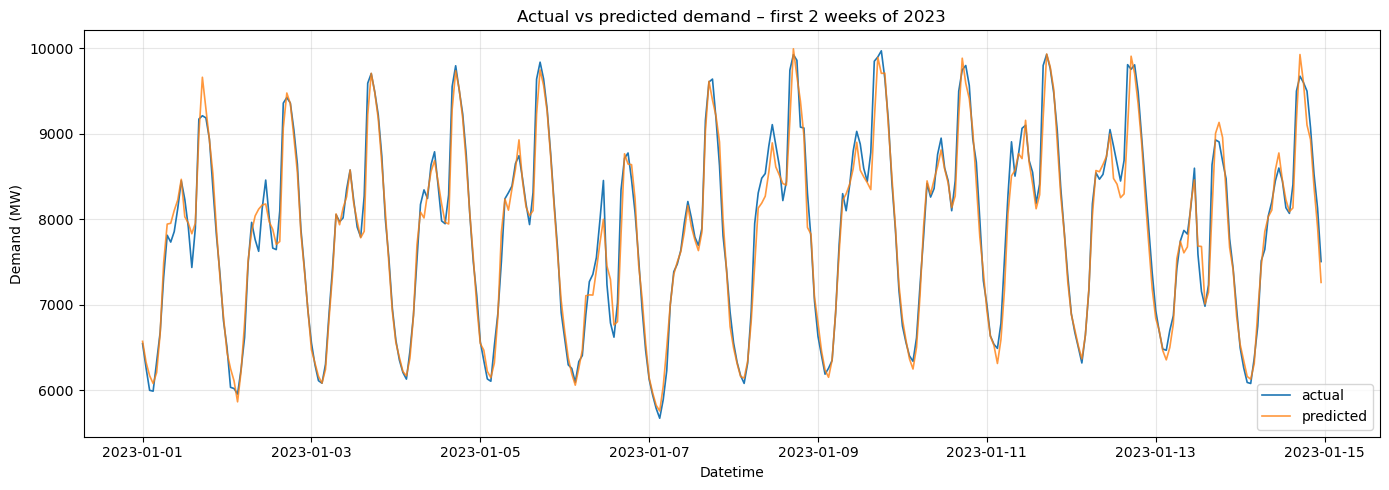

In [ ]:
#  actual vs predicted plot for the first 2 weeks of the test set 
import matplotlib.pyplot as plt

plot_df = test_df[['datetime']].copy()
plot_df['actual']    = y_test.values
plot_df['predicted'] = y_pred

# first 14 * 24 = 336 hours = 2 weeks
first_two_weeks = plot_df.iloc[:14*24]

plt.figure(figsize=(14, 5))
plt.plot(first_two_weeks['datetime'], first_two_weeks['actual'],    label='actual',    linewidth=1.2)
plt.plot(first_two_weeks['datetime'], first_two_weeks['predicted'], label='predicted', linewidth=1.2, alpha=0.8)
plt.title('Actual vs predicted demand – first 2 weeks of 2023')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted_first_2_weeks.png', dpi=120)
plt.show()


## Which features mattered most?

XGBoost gives a feature_importances  attribute. I'll plot the top 20 as a simple horizontal bar chart to see which of my inputs actually pulled their weight.


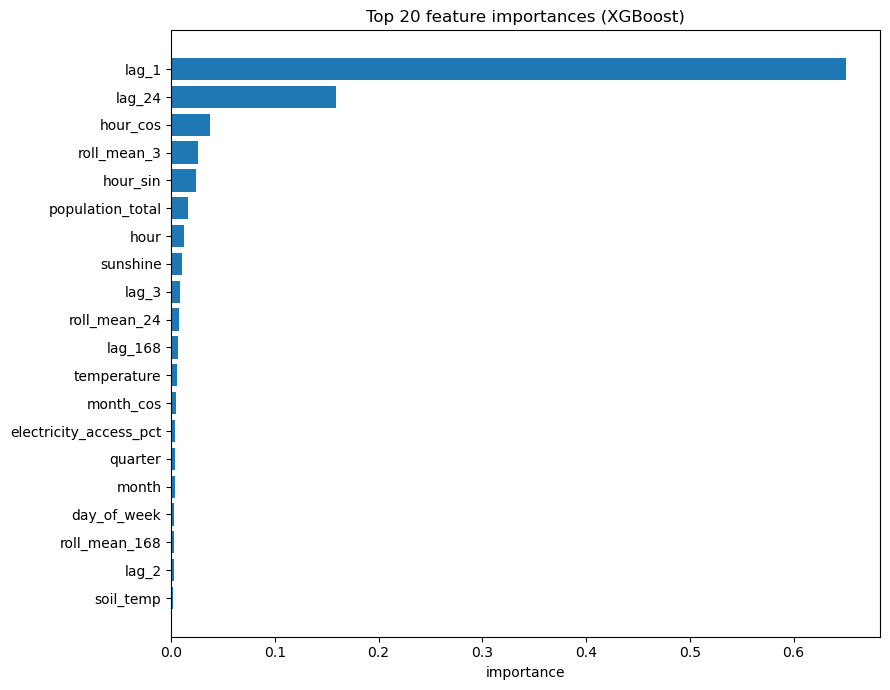

lag_1                     0.650843
lag_24                    0.158995
hour_cos                  0.037418
roll_mean_3               0.025410
hour_sin                  0.023994
population_total          0.015803
hour                      0.012501
sunshine                  0.010863
lag_3                     0.008502
roll_mean_24              0.007577
lag_168                   0.006241
temperature               0.005516
month_cos                 0.004308
electricity_access_pct    0.003805
quarter                   0.003602
month                     0.003218
day_of_week               0.002382
roll_mean_168             0.002325
lag_2                     0.002235
soil_temp                 0.002179
dtype: float32


In [32]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)   # ascending for barh so the biggest is on top

top20 = importances.tail(20)

plt.figure(figsize=(9, 7))
plt.barh(top20.index, top20.values)
plt.title('Top 20 feature importances (XGBoost)')
plt.xlabel('importance')
plt.tight_layout()
plt.savefig('feature_importance_top20.png', dpi=120)
plt.show()

# also print the full ranking so I can see numbers
print(importances.sort_values(ascending=False).head(20))


 Save predictions to CSV



In [33]:
predictions_out = pd.DataFrame({
    'datetime'           : test_df['datetime'].values,
    'actual_demand'      : y_test.values,
    'predicted_demand'   : y_pred,
})
predictions_out.to_csv('predictions_2023.csv', index=False)
print("saved predictions_2023.csv, shape =", predictions_out.shape)
predictions_out.head()


saved predictions_2023.csv, shape = (8760, 3)


,datetime,actual_demand,predicted_demand
0,2023-01-01 00:00:00,6544.0,6571.223145
1,2023-01-01 01:00:00,6258.0,6326.050781
2,2023-01-01 02:00:00,5998.0,6169.581543
3,2023-01-01 03:00:00,5988.0,6077.881836
4,2023-01-01 04:00:00,6331.0,6205.379883
